# Analyse Exploratoire des Données (EDA)
## US Accidents (2016–2023)

Ce notebook présente la phase d’exploration et de nettoyage du dataset US-Accidents.
L’objectif est de comprendre la structure des données, identifier les problèmes de qualité
et préparer les variables pour les analyses statistiques avancées.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


Chargement INTELLIGENT du dataset (CRUCIAL ⚠️)

In [3]:
import pandas as pd
import numpy as np

# Colonnes à charger
cols = [
    "Severity",
    "Start_Time",
    "End_Time",
    "State",
    "City",
    "Weather_Condition",
    "Visibility(mi)",
    "Temperature(F)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

# Chargement du CSV
df = pd.read_csv(
    "D:/FormationSimplon/Breifs/Analyse Statistique Avancée des Accidents de la Route aux États-Unis/Breifs7/StatistiqueAvancee/data/raw/US_Accidents.csv",
    usecols=cols,
    parse_dates=["Start_Time", "End_Time"],
    low_memory=False
)

# Vérification
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'D:/FormationSimplon/Breifs/Analyse Statistique Avancée des Accidents de la Route aux États-Unis/Breifs7/StatistiqueAvancee/data/raw/US_Accidents.csv'

Aperçu général

Le dataset contient plusieurs millions de lignes avec des variables temporelles,
géographiques et météorologiques. Certaines colonnes présentent des valeurs manquantes,
notamment les variables météo.

In [38]:
df.head()


,Severity,Start_Time,End_Time,City,State,Temperature(F),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition
0,3,2016-02-08 05:46:00,2016-02-08 11:00:00,Dayton,OH,36.9,10.0,NaN,0.02,Light Rain
1,2,2016-02-08 06:07:59,2016-02-08 06:37:59,Reynoldsburg,OH,37.9,10.0,NaN,0.00,Light Rain
2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,Williamsburg,OH,36.0,10.0,3.5,NaN,Overcast
3,3,2016-02-08 07:23:34,2016-02-08 07:53:34,Dayton,OH,35.1,9.0,4.6,NaN,Mostly Cloudy
4,2,2016-02-08 07:39:07,2016-02-08 08:09:07,Dayton,OH,36.0,6.0,3.5,NaN,Mostly Cloudy


In [39]:
df.shape


(7728394, 10)

In [40]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 10 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int64  
 1   Start_Time         object 
 2   End_Time           object 
 3   City               object 
 4   State              object 
 5   Temperature(F)     float64
 6   Visibility(mi)     float64
 7   Wind_Speed(mph)    float64
 8   Precipitation(in)  float64
 9   Weather_Condition  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 589.6+ MB


Valeurs manquantes

Les variables météorologiques présentent un taux de valeurs manquantes significatif,
ce qui nécessite une stratégie de traitement adaptée (imputation ou exclusion ciblée).

In [41]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing


Precipitation(in)    28.512858
Wind_Speed(mph)       7.391355
Visibility(mi)        2.291524
Weather_Condition     2.244438
Temperature(F)        2.120143
City                  0.003274
Start_Time            0.000000
Severity              0.000000
State                 0.000000
End_Time              0.000000
dtype: float64

Nettoyage de base

In [42]:
# Suppression des lignes sans date
df = df.dropna(subset=["Start_Time", "End_Time"])

# Remplacement des valeurs manquantes météo par la médiane
for col in ["Visibility(mi)", "Temperature(F)", "Wind_Speed(mph)", "Precipitation(in)"]:
    df[col] = df[col].fillna(df[col].median())


Feature Engineering (IMPORTANT)

Des variables temporelles ont été créées afin d’analyser les patterns horaires,
hebdomadaires et saisonniers des accidents.

In [1]:
df["hour"] = df["Start_Time"].dt.hour
df["day_of_week"] = df["Start_Time"].dt.day_name()
df["month"] = df["Start_Time"].dt.month
df["is_weekend"] = df["Start_Time"].dt.weekday >= 5


NameError: name 'df' is not defined

In [45]:
#Vérification
df.dtypes


Severity               int64
Start_Time            object
End_Time              object
City                  object
State                 object
Temperature(F)       float64
Visibility(mi)       float64
Wind_Speed(mph)      float64
Precipitation(in)    float64
Weather_Condition     object
dtype: object

In [54]:
#Valide Code Pour Feature Engineering
df["hour"] = df["Start_Time"].dt.hour
df["day_of_week"] = df["Start_Time"].dt.day_name()
df["month"] = df["Start_Time"].dt.month
df["is_weekend"] = df["Start_Time"].dt.weekday >= 5
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"], errors="coerce")


Distribution de la gravité

La majorité des accidents sont de gravité modérée, tandis que les accidents très graves
sont moins fréquents.


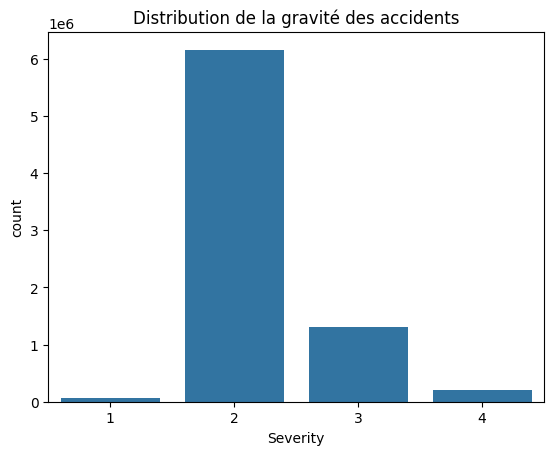

In [47]:
sns.countplot(data=df, x="Severity")
plt.title("Distribution de la gravité des accidents")
plt.show()


Accidents par heure

Les pics d’accidents apparaissent durant les heures de pointe (matin et fin de journée),
ce qui suggère un lien fort avec le trafic.


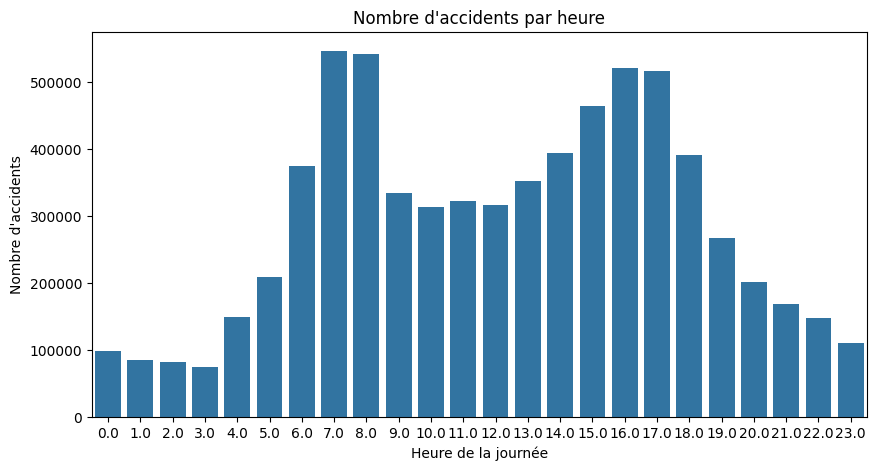

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="hour")
plt.title("Nombre d'accidents par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre d'accidents")
plt.show()


Accidents semaine vs week-end



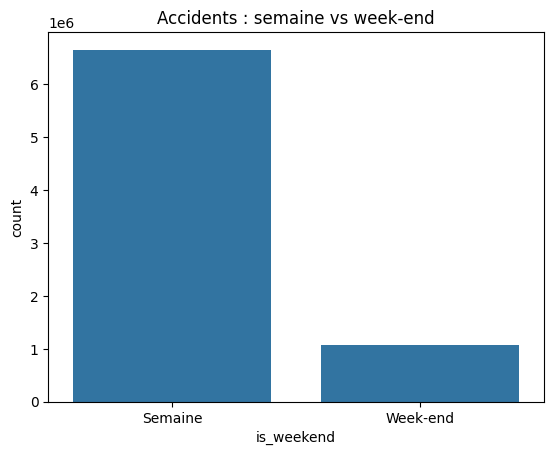

In [55]:


sns.countplot(data=df, x="is_weekend")
plt.xticks([0,1], ["Semaine", "Week-end"])
plt.title("Accidents : semaine vs week-end")
plt.show()


Météo & gravité

Une faible visibilité est associée à des accidents plus graves, ce qui justifie
l’utilisation de tests statistiques dans la suite du projet.


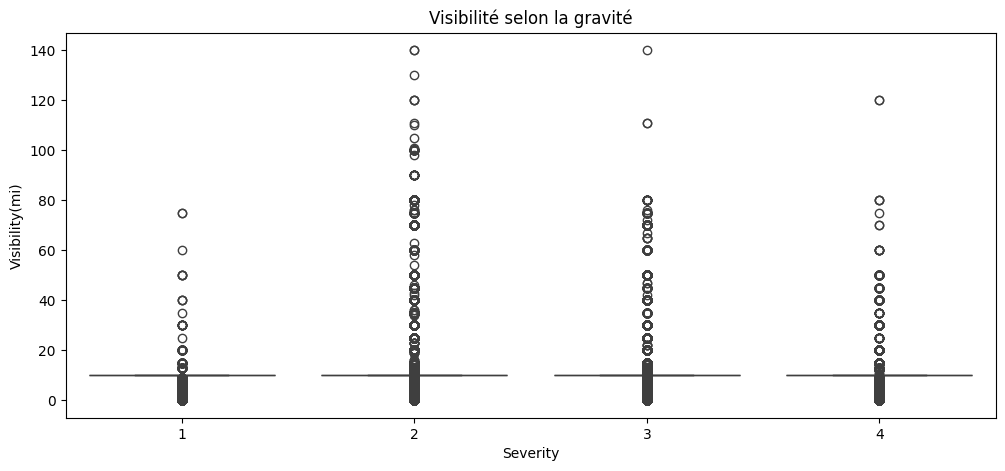

In [56]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="Severity", y="Visibility(mi)")
plt.title("Visibilité selon la gravité")
plt.show()


## Sauvegarde des données nettoyées

In [58]:
df.to_csv("../data/processed/us_accidents_clean.csv", index=False)
print("Fichier sauvegardé avec succès.")



Fichier sauvegardé avec succès.
